In [2]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize, curve_fit
from emcee import EnsembleSampler

import matplotlib.pyplot as plt

In [3]:
#read in data
df = pd.read_csv("tau_data.csv")
df['Actual Counts'] = df['Coincident Counts'] * 1000

In [4]:
#plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15

In [5]:
def step_model(x, center, width, steepness, amplitude, noise):
    x = np.array(x)
    y = amplitude * np.exp(-((np.abs(x - center) / width)**steepness)) + noise
    return y

In [6]:
def loss(theta):
    y_mod = step_model(df["Actual Tau?"], *theta)
    y_data = df["Actual Counts"]
    return np.sum((y_data - y_mod)**2/y_data)

In [9]:
p0 = [15, 15, 2, 2000, 100]
opt_res = minimize(lambda p: loss(np.exp(p)), np.log(p0), method="Nelder-Mead")
tau_fit = np.exp(opt_res.x)[0]
width_fit = np.exp(opt_res.x)[1]

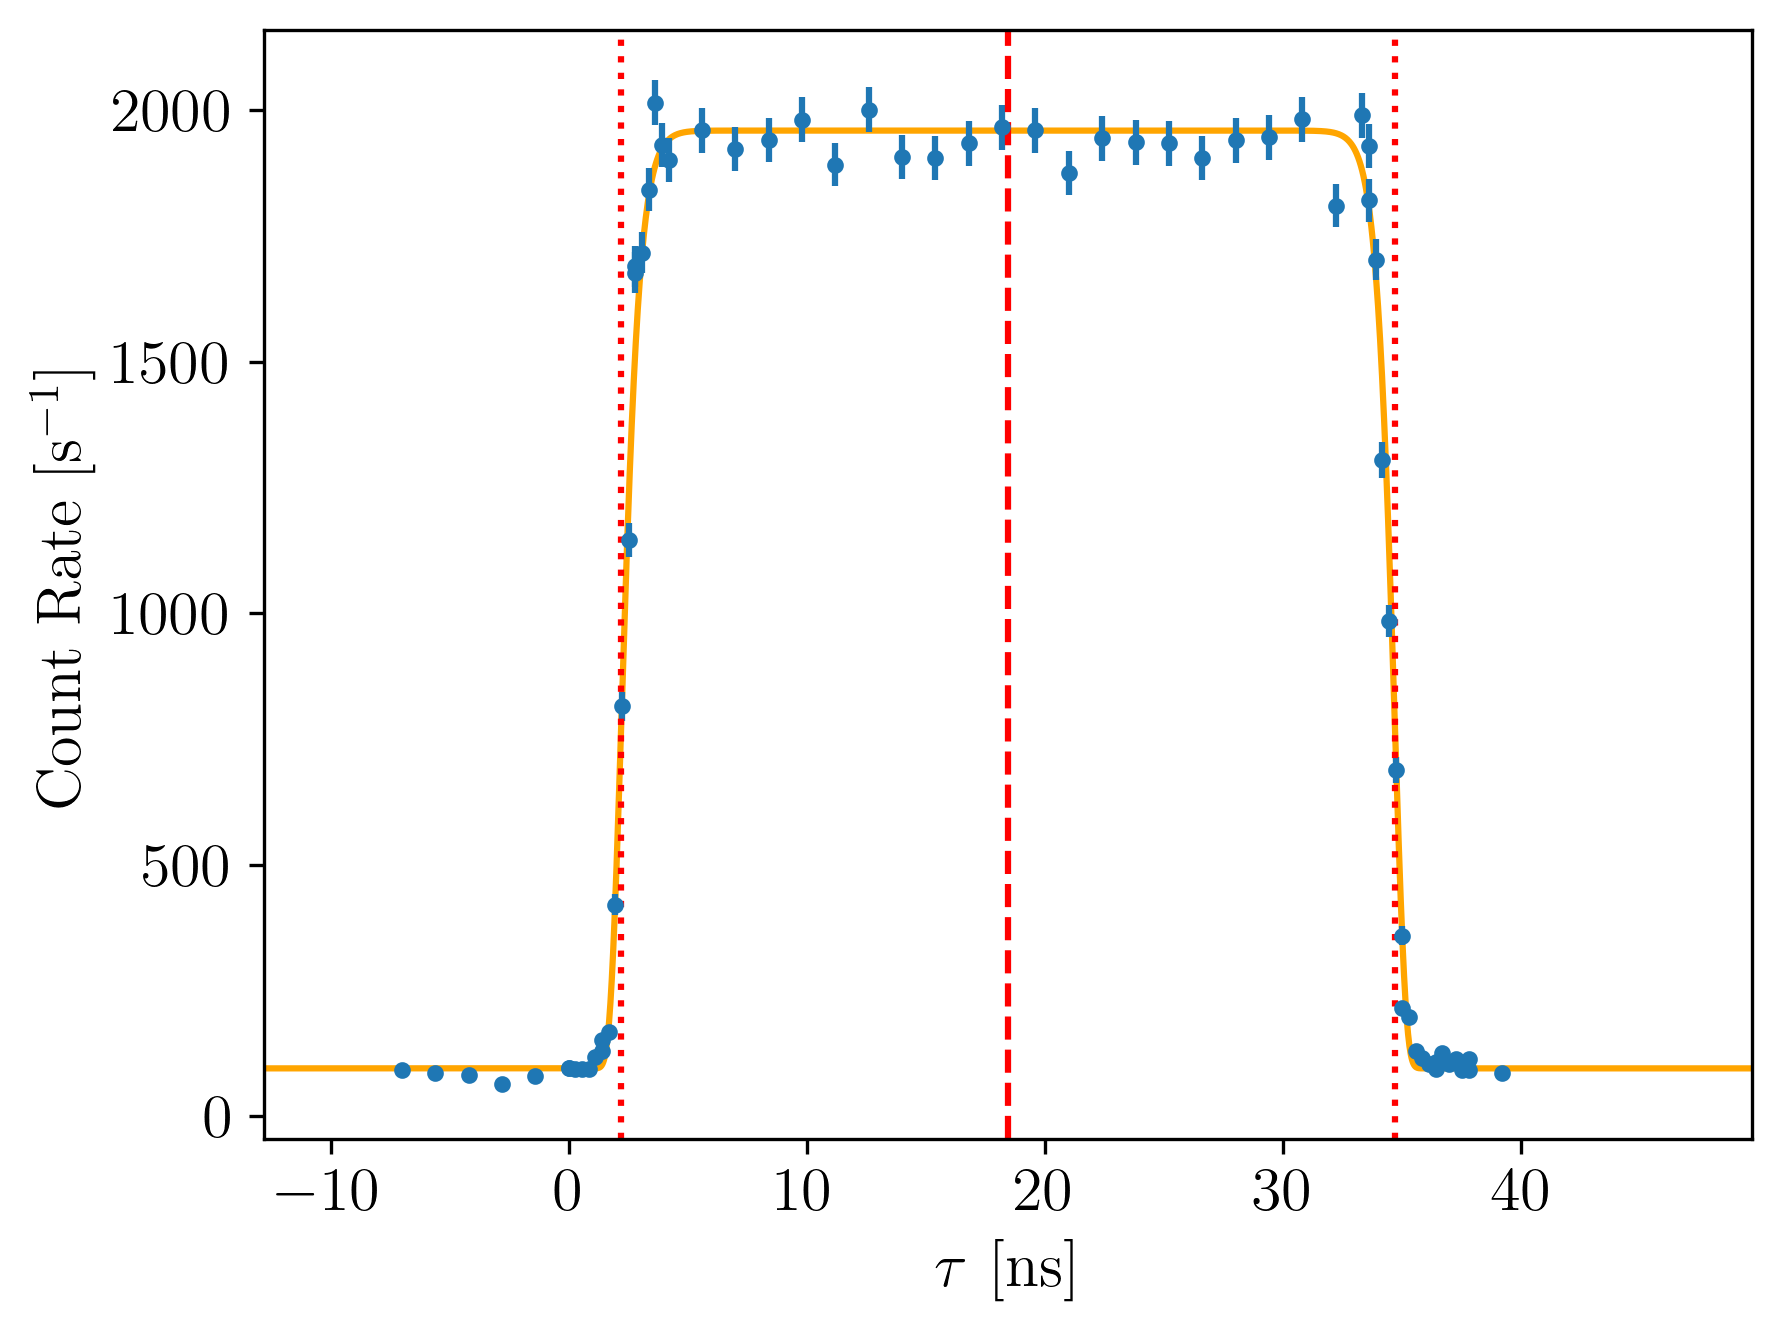

In [10]:
fig, ax = plt.subplots(dpi = 300)

x = np.linspace(-70, 70, 5000)
y = step_model(x, *np.exp(opt_res.x))
ax.plot(x, y, color = "orange")
ax.errorbar(df['Actual Tau?'], df['Actual Counts'], np.sqrt(df['Actual Counts']), ls="", marker = ".")
ax.set_xlabel("$\\tau$ [ns]")
ax.set_ylabel("Count Rate $[\\text{s}^{-1}]$")
ax.axvline(tau_fit, ls = "dashed", color = "red")
ax.axvline(tau_fit + width_fit, ls = "dotted", color = "red")
ax.axvline(tau_fit - width_fit, ls = "dotted", color = "red")
ax.set_xlim(tau_fit - width_fit - 15, tau_fit + width_fit + 15)
plt.savefig("figures/tau_fit.png")

In [11]:
#mcmc prior
def log_prior(theta):
    if np.any(theta < 0):
        return -np.inf
    
    return 0

#mcmc log likelihood
def log_prob(theta):
    if log_prior(theta) == -np.inf:
        return -np.inf
    
    return -loss(theta)

In [12]:
#initialize mcmc walkers
N_WALKERS = 16
BUMP_SIZE = 1
x0 = np.exp(opt_res.x) + BUMP_SIZE * np.random.randn(N_WALKERS, len(opt_res.x))

In [13]:
#run mcmc
sampler = EnsembleSampler(N_WALKERS, x0.shape[1], log_prob)
sampler.run_mcmc(x0, 25_000, progress=True)

100%|██████████| 25000/25000 [01:26<00:00, 289.30it/s]


State([[  18.41531537   16.20169537   37.23751136 1862.88435964  100.55219331]
 [  18.41577028   16.20405479   36.7218006  1862.25487844  103.61202805]
 [  18.41369709   16.21042191   36.97801769 1843.97667915   98.82750277]
 [  18.41847554   16.21427364   37.49858906 1843.82999049   98.60158947]
 [  18.41211233   16.20073793   36.77668234 1861.25019216   99.73299988]
 [  18.41601271   16.20753128   37.60423153 1838.13735873  101.48371612]
 [  18.41494066   16.20804755   36.86390789 1848.51622245   95.76542673]
 [  18.41770477   16.21015749   37.13804725 1851.11925931  100.58726659]
 [  18.41363988   16.21086672   36.80273492 1849.89398113   99.47219176]
 [  18.42631362   16.20108276   36.97052206 1862.76044672  100.74654077]
 [  18.41568406   16.21128711   36.87440995 1851.65545693   99.53367372]
 [  18.40801147   16.21017154   37.29537302 1850.73404676  100.04220832]
 [  18.41897776   16.2135284    37.18381278 1850.96186468   99.47584721]
 [  18.41275825   16.21683636   37.43772542 1

In [14]:
#names of parameters
param_labels = ["Center",
                "Width",
                "Steepness",
                "Amplitude",
                "Noise"]

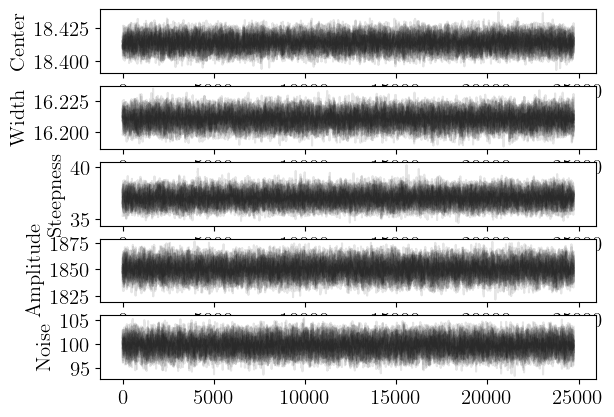

In [15]:
#check fit stability 
autocorr_time = sampler.get_autocorr_time()
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)))
for dim_n in range(chain.shape[2]):
    ax = plt.subplot(chain.shape[2], 1, dim_n + 1)
    ax.set_ylabel(param_labels[dim_n])
    for walker_n in range(chain.shape[1]):
        plt.plot(chain[:, walker_n, dim_n], c='black', alpha=0.1)

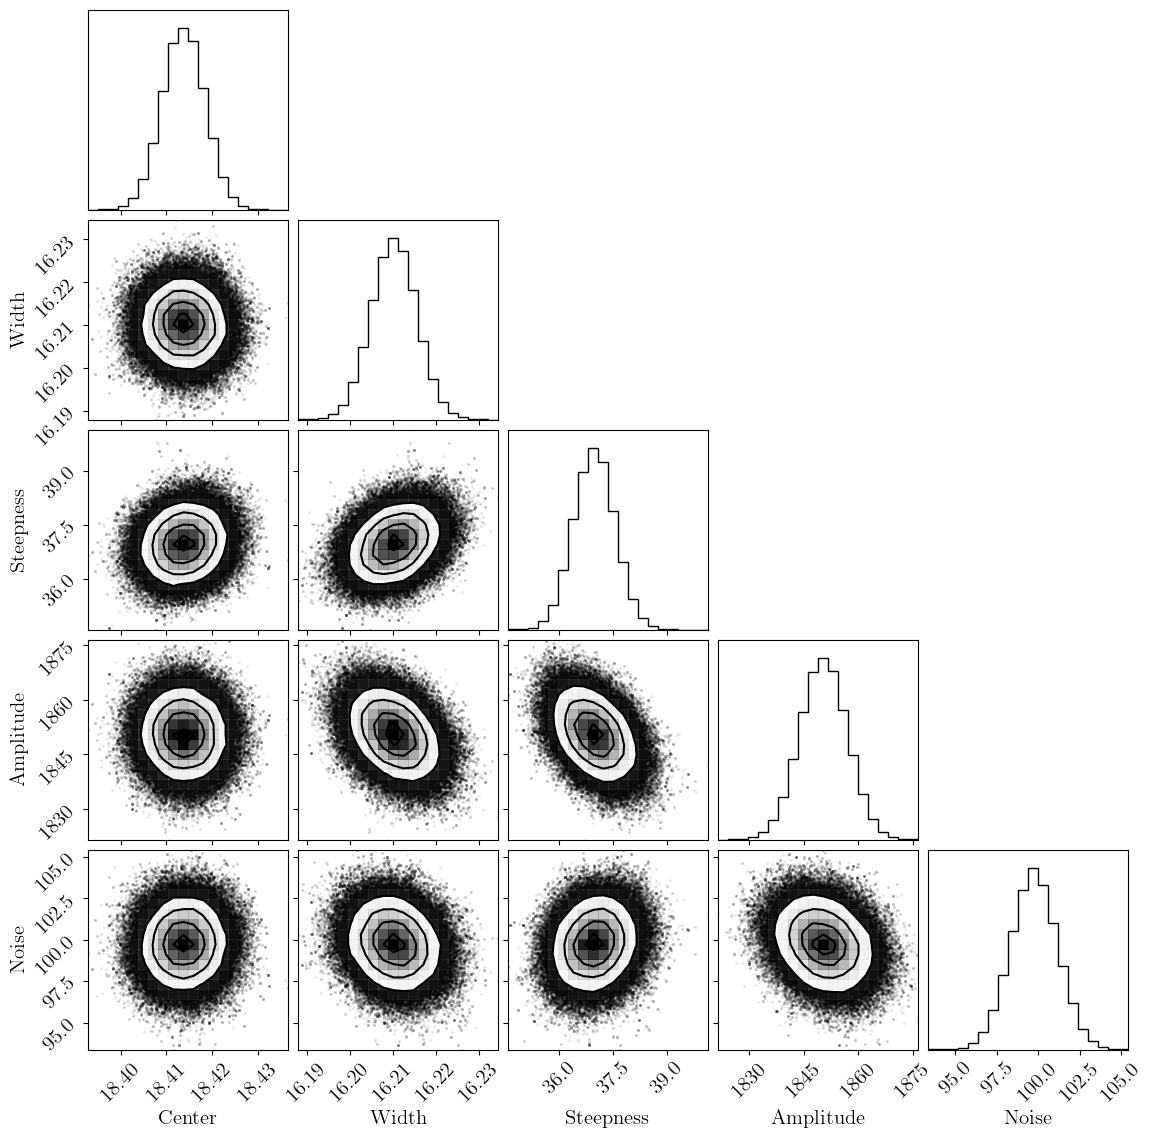

In [16]:
#examine posterior distributions of parameters
import corner
corner.corner(sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True), labels=param_labels);

In [17]:
chain = sampler.get_chain(flat=True, discard=int(np.max(autocorr_time*4)))
results = pd.DataFrame(
    {
        "Median Value": np.median(chain, axis = 0),
        "2-sigma Uncertainty": np.sqrt(np.diag(np.cov(chain.T))) * 2
    },
    index=param_labels
)
results["Uncertainty/Value"] = results["2-sigma Uncertainty"]/results["Median Value"]

In [18]:
results

,Median Value,2-sigma Uncertainty,Uncertainty/Value
Center,18.413839,0.009278,0.000504
Width,16.210387,0.010524,0.000649
Steepness,36.987044,1.141429,0.030860
Amplitude,1850.476832,12.966542,0.007007
Noise,99.774916,2.828346,0.028347
